M3: Sistema Multiagente de AGVs

Centro de distribucion virtual con una flota de AGVs que se coordina por **subasta descentralizada**.

Este notebook parte del entorno logistico construido en M2 y le agrega la capa multiagente:

Agentes -> Interaccion -> Comunicacion -> Colaboracion -> Negociacion

Instalacion de AgentPy


In [16]:
!pip install agentpy -q

Importar todo lo que usa el entorno

In [17]:
import random
from collections import deque
from dataclasses import dataclass, field
from enum import Enum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import agentpy as ap

### Semilla de reproducibilidad

Se fija la semilla de random y de numpy para que la corrida completa (generacion de pallets, misiones y desempates de subasta) sea identica en cada ejecucion.

In [18]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Semilla fija:", SEED)

Semilla fija: 42


Se uso el mismo entorno que en la M2

In [19]:

ANCHO = 40
ALTO  = 26

LINEAS_PRODUCCION = {
    "PL-1": (1, 21, 6, 3),
    "PL-2": (1, 16, 6, 3),
    "PL-3": (1, 11, 6, 3),
    "PL-4": (1,  6, 6, 3),
}

RACKS = {
    "R-A1": (12, 15, 3, 8),  "R-A2": (12, 4, 3, 8),
    "R-B1": (18, 15, 3, 8),  "R-B2": (18, 4, 3, 8),
    "R-C1": (24, 15, 3, 8),  "R-C2": (24, 4, 3, 8),
}

TRUCK_DOCKS = {
    "DOCK-1": (36, 19, 3, 4),
    "DOCK-2": (36, 13, 3, 4),
    "DOCK-3": (36,  7, 3, 4),
}

ESTACIONES_CARGA = {
    "CS-1": (9,  1, 2, 2),
    "CS-2": (30, 1, 2, 2),
    "CS-3": (30, 23, 2, 2),
}

OBSTACULOS = {
    "OFICINA":   (1, 1, 5, 3),
    "MANTTO":    (33, 1, 4, 3),
    "COLUMNA-1": (9, 13, 1, 1),
    "COLUMNA-2": (29, 13, 1, 1),
}

PALLETS = {
    "P-PL1": (8, 22), "P-PL2": (8, 17), "P-PL3": (8, 12), "P-PL4": (8, 7),
    "P-RA": (16, 19), "P-RB": (22, 8),  "P-RC": (28, 19),
    "P-D1": (34, 20), "P-D2": (34, 14), "P-D3": (34, 8),
}

print("Entorno definido:", ANCHO, "x", ALTO, "celdas")

Entorno definido: 40 x 26 celdas


### Matriz de ocupacion

grid es la matriz binaria de transitabilidad: 0 corredor libre, 1 zona bloqueada. Es la entrada del ruteo de los AGVs.

In [20]:
# 0 = zona accesible (corredores)
# 1 = zona bloqueada (racks, lineas de produccion, obstaculos)
grid = np.zeros((ALTO, ANCHO), dtype=int)

# Se bloquean
def bloquear(elementos):
    for (x, y, w, h) in elementos.values():
        grid[y:y+h, x:x+w] = 1

bloquear(LINEAS_PRODUCCION)
bloquear(RACKS)
bloquear(OBSTACULOS)

libres = int((grid == 0).sum())
print("Celdas totales:", grid.size)
print("Celdas transitables:", libres, f"({100*libres/grid.size:.1f}%)")
print("Celdas bloqueadas:", int((grid == 1).sum()))

Celdas totales: 1040
Celdas transitables: 795 (76.4%)
Celdas bloqueadas: 245


### Plano estatico del almacen

Dibujo del layout con todas las zonas etiquetadas y su leyenda.

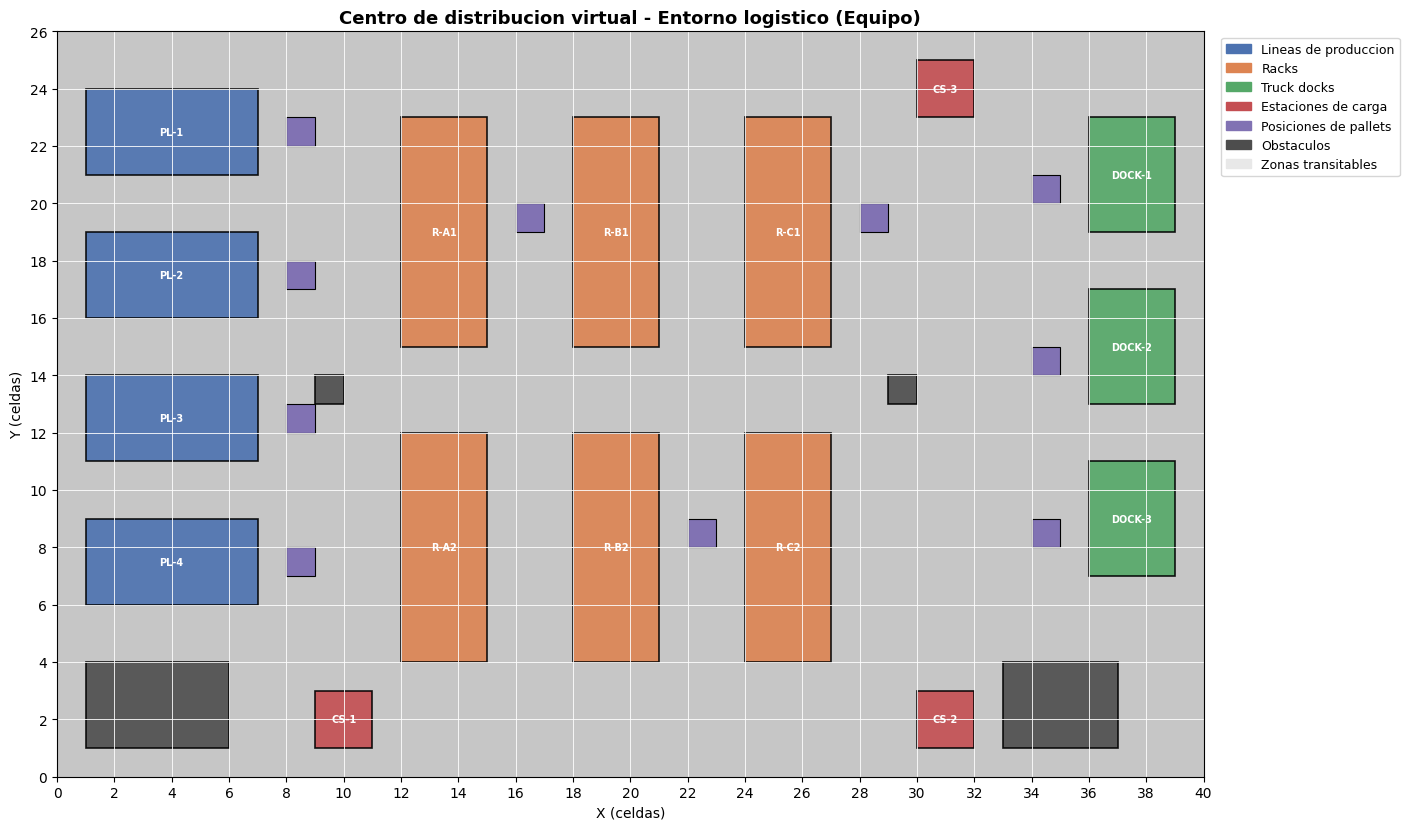

In [21]:
COL = {
    "linea": "#4C72B0", "rack": "#DD8452", "dock": "#55A868",
    "carga": "#C44E52", "pallet": "#8172B3", "obst": "#4D4D4D",
}

fig, ax = plt.subplots(figsize=(14, 9))

def dibujar(elementos, color, alpha=0.9, etiqueta=True):
    for nombre, (x, y, w, h) in elementos.items():
        ax.add_patch(patches.Rectangle((x, y), w, h, facecolor=color,
                                       edgecolor="black", linewidth=1.2, alpha=alpha))
        if etiqueta:
            ax.text(x + w/2, y + h/2, nombre, ha="center", va="center",
                    fontsize=7, color="white", weight="bold")

# Fondo de zonas transitables
ax.imshow(np.ones_like(grid), cmap="Greys", vmin=0, vmax=3,
          extent=[0, ANCHO, 0, ALTO], origin="lower")

dibujar(LINEAS_PRODUCCION, COL["linea"])
dibujar(RACKS,             COL["rack"])
dibujar(TRUCK_DOCKS,       COL["dock"])
dibujar(ESTACIONES_CARGA,  COL["carga"])
dibujar(OBSTACULOS,        COL["obst"], etiqueta=False)

# Pallets como cuadros pequenos
for nombre, (x, y) in PALLETS.items():
    ax.add_patch(patches.Rectangle((x, y), 1, 1, facecolor=COL["pallet"],
                                   edgecolor="black", linewidth=0.8))

# Rejilla y ejes
ax.set_xticks(range(0, ANCHO + 1, 2))
ax.set_yticks(range(0, ALTO + 1, 2))
ax.grid(True, color="white", linewidth=0.6)
ax.set_xlim(0, ANCHO); ax.set_ylim(0, ALTO)
ax.set_aspect("equal")
ax.set_xlabel("X (celdas)"); ax.set_ylabel("Y (celdas)")
ax.set_title("Centro de distribucion virtual - Entorno logistico (Equipo)", fontsize=13, weight="bold")

leyenda = [
    patches.Patch(color=COL["linea"],  label="Lineas de produccion"),
    patches.Patch(color=COL["rack"],   label="Racks"),
    patches.Patch(color=COL["dock"],   label="Truck docks"),
    patches.Patch(color=COL["carga"],  label="Estaciones de carga"),
    patches.Patch(color=COL["pallet"], label="Posiciones de pallets"),
    patches.Patch(color=COL["obst"],   label="Obstaculos"),
    patches.Patch(color="#E8E8E8",     label="Zonas transitables"),
]
ax.legend(handles=leyenda, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()

##FLujos Logisticos

Produccion -> Rack, Rack -> Truck Dock y Truck Dock -> Rack.

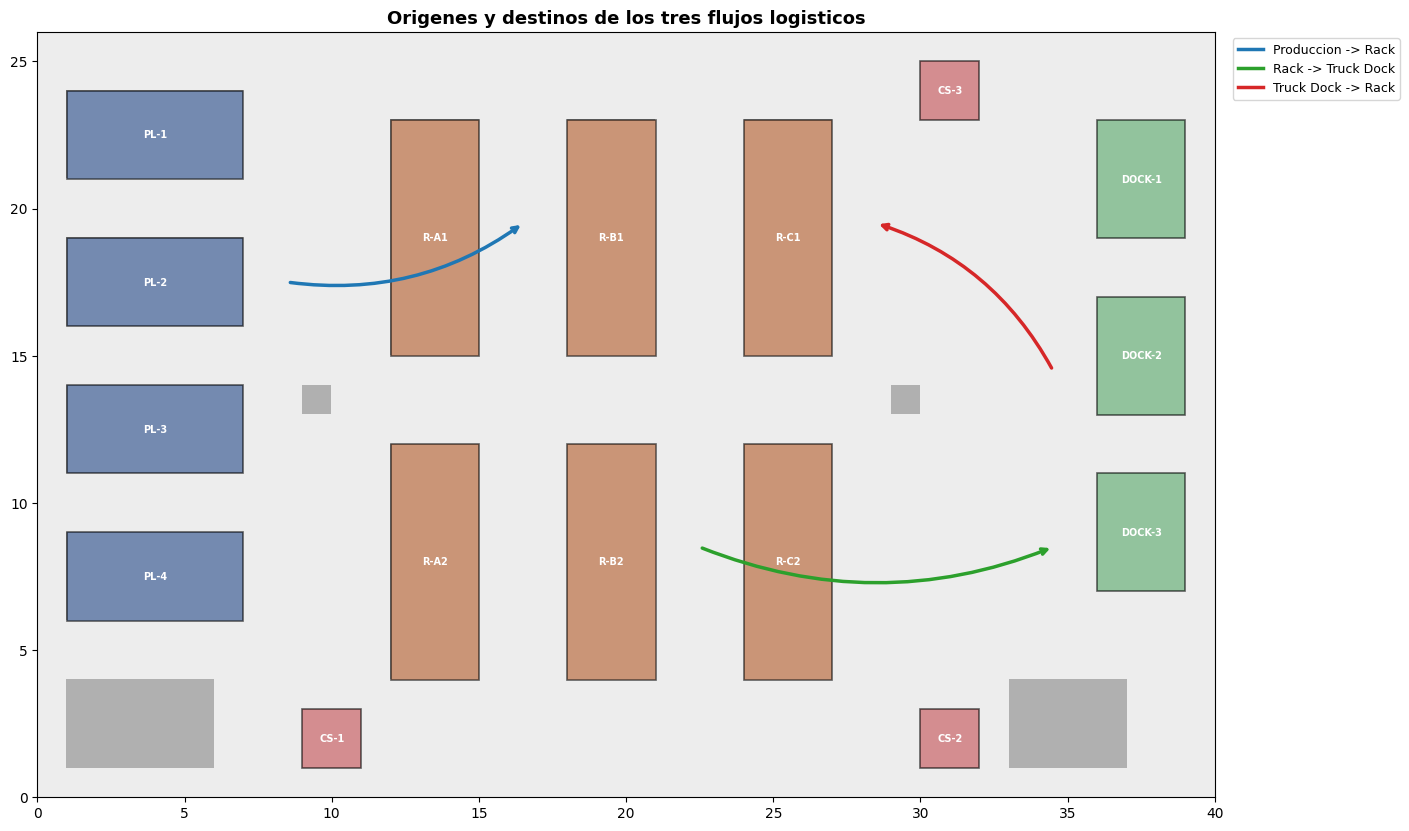

In [22]:
FLUJOS = [
    ("Produccion -> Rack",  PALLETS["P-PL2"], PALLETS["P-RA"], "#1f77b4"),
    ("Rack -> Truck Dock",  PALLETS["P-RB"],  PALLETS["P-D3"], "#2ca02c"),
    ("Truck Dock -> Rack",  PALLETS["P-D2"],  PALLETS["P-RC"], "#d62728"),
]

fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(grid, cmap=plt.cm.colors.ListedColormap(["#EDEDED", "#B0B0B0"]),
          extent=[0, ANCHO, 0, ALTO], origin="lower")

dibujar(LINEAS_PRODUCCION, COL["linea"], alpha=0.6)
dibujar(RACKS,             COL["rack"],  alpha=0.6)
dibujar(TRUCK_DOCKS,       COL["dock"],  alpha=0.6)
dibujar(ESTACIONES_CARGA,  COL["carga"], alpha=0.6)

for nombre, (x0, y0), (x1, y1), color in FLUJOS:
    ax.annotate("", xy=(x1 + 0.5, y1 + 0.5), xytext=(x0 + 0.5, y0 + 0.5),
                arrowprops=dict(arrowstyle="->", lw=2.5, color=color,
                                connectionstyle="arc3,rad=0.2"))
    ax.plot([], [], color=color, lw=2.5, label=nombre)

ax.set_xlim(0, ANCHO); ax.set_ylim(0, ALTO); ax.set_aspect("equal")
ax.set_title("Origenes y destinos de los tres flujos logisticos", fontsize=13, weight="bold")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()

### Analisis del entorno

**¿Cómo representamos computacionalmente el entorno?**
Como un tipo grid 2D de 40 x 26 celdas con origen en la esquina inferior izquierda.
Cada elemento logístico se define como una tupla (x, y, w, h), lo que permite
una correspondencia directa con el plano XZ de Unity. Además se genera una matriz
de ocupación grid donde 0 es zona transitable y 1 es zona bloqueada.

**¿Qué elementos incluimos?**
4 líneas de produccion, 6 racks organizados en 3 pasillos dobles, 3 truck docks, 3 estaciones de carga, 10 posiciones de pallets, obstáculos fijos (oficina, área de mantenimiento y dos columnas estructurales) y los corredores de circulación.

**¿Qué personalizamos?**
Se cambio todo el layout.
Cambiamos las dimensiones del almacén, aumentamos a 4 líneas de producción,
reorganizamos los racks en pasillos verticales dobles, movimos los truck docks
al costado derecho, agregamos una tercera estación de carga, definimos obstáculos
propios y colocamos las posiciones de pallets en los puntos de entrada y salida
de cada zona.

**¿Por qué elegimos esa distribución?**
Separa el flujo en tres bandas: producción a la izquierda, almacenamiento al
centro y sacar las cosas a la derecha. Esto genera un flujo bastante simple,
reduce problemas de tráfico y deja corredores continuos entre pasillos de racks,
además de un anillo perimetral que permite rutas alternativas.

**¿Cómo representamos zonas transitables y obstáculos?**
Con la matriz binaria grid. Racks, líneas de producción y obstáculos se marcan
como no atravesables. Los docks y las estaciones de carga se dejan accesibles
porque son destinos. Todo lo demás esta libre.

**¿Dónde están los orígenes y destinos de los tres flujos?**
- Production Line -> Rack / Truck Dock: origen en los pallets P-PL1 a P-PL4, destino en los pallets de rack o de dock.
- Rack -> Truck Dock: origen en P-RA, P-RB, P-RC, destino en P-D1, P-D2, P-D3.
- Truck Dock -> Rack: origen en los pallets de dock, destino en los pallets de rack.

**¿Qué será importante al incorporar la lógica de los AGVs?**
La matriz de ocupación (base para el ruteo), el ancho de los corredores (evitar
bloqueos mutuos), la ubicación de las estaciones de carga respecto a las rutas
principales, y las posiciones de pallets como puntos discretos de pickup y drop-off.

### Resumen del entorno

Se define es_transitable(x, y), la funcion que usaran los AGVs para rutear y se utiliza.

**Nota sobre el layout:** los docks de M2 no estan separados en entrada y salida. En la Fase 2 se les asigna un rol logico (IN / OUT) sin mover ninguna coordenada.

In [23]:
def es_transitable(x, y):
    return 0 <= x < ANCHO and 0 <= y < ALTO and grid[y, x] == 0

ZONAS = {
    "Lineas de produccion": LINEAS_PRODUCCION,
    "Racks": RACKS,
    "Truck docks": TRUCK_DOCKS,
    "Estaciones de carga": ESTACIONES_CARGA,
    "Obstaculos": OBSTACULOS,
}

for nombre, zona in ZONAS.items():
    print(f"{nombre:22s} {len(zona):2d}  {', '.join(zona)}")
print(f"{'Posiciones de pallet':22s} {len(PALLETS):2d}  {', '.join(PALLETS)}")

libres = int((grid == 0).sum())
print(f"\nGrid {grid.shape}: {libres} celdas transitables, {grid.size - libres} bloqueadas")
print("Pallets sobre celda no transitable:",
      [n for n, (x, y) in PALLETS.items() if not es_transitable(x, y)] or "ninguno")

Lineas de produccion    4  PL-1, PL-2, PL-3, PL-4
Racks                   6  R-A1, R-A2, R-B1, R-B2, R-C1, R-C2
Truck docks             3  DOCK-1, DOCK-2, DOCK-3
Estaciones de carga     3  CS-1, CS-2, CS-3
Obstaculos              4  OFICINA, MANTTO, COLUMNA-1, COLUMNA-2
Posiciones de pallet   10  P-PL1, P-PL2, P-PL3, P-PL4, P-RA, P-RB, P-RC, P-D1, P-D2, P-D3

Grid (26, 40): 795 celdas transitables, 245 bloqueadas
Pallets sobre celda no transitable: ninguno


---

Objetos del dominio

Pallets y misiones como estructuras de datos propias, separadas de la infraestructura del almacen.



### Roles de dock y puntos logisticos

 Aqui se les asigna un rol logico a los docks: DOCK-3 es entrada, DOCK-1 y DOCK-2 son salida.



In [24]:
DOCKS_IN = ["DOCK-3"]
DOCKS_OUT = ["DOCK-1", "DOCK-2"]

PUNTOS_PRODUCCION = ["P-PL1", "P-PL2", "P-PL3", "P-PL4"]
PUNTOS_RACK = ["P-RA", "P-RB", "P-RC"]
PUNTOS_DOCK_IN = ["P-D3"]
PUNTOS_DOCK_OUT = ["P-D1", "P-D2"]

FLUJOS_M3 = [
    ("Produccion -> Rack",     PUNTOS_PRODUCCION, PUNTOS_RACK),
    ("Produccion -> Dock OUT", PUNTOS_PRODUCCION, PUNTOS_DOCK_OUT),
    ("Rack -> Dock OUT",       PUNTOS_RACK,       PUNTOS_DOCK_OUT),
    ("Dock IN -> Rack",        PUNTOS_DOCK_IN,    PUNTOS_RACK),
]

for nombre, origenes, destinos in FLUJOS_M3:
    print(f"{nombre:24s} {origenes}  ->  {destinos}")

Produccion -> Rack       ['P-PL1', 'P-PL2', 'P-PL3', 'P-PL4']  ->  ['P-RA', 'P-RB', 'P-RC']
Produccion -> Dock OUT   ['P-PL1', 'P-PL2', 'P-PL3', 'P-PL4']  ->  ['P-D1', 'P-D2']
Rack -> Dock OUT         ['P-RA', 'P-RB', 'P-RC']  ->  ['P-D1', 'P-D2']
Dock IN -> Rack          ['P-D3']  ->  ['P-RA', 'P-RB', 'P-RC']


### Estados y estructuras

Pallet y Mission son dataclasses, no diccionarios sueltos.

**Rack distinto de pallet:** el rack es infraestructura fija del almacen, esta en RACKS como un rectangulo que nunca se mueve y bloquea el grid. El pallet es un objeto con (id, position, status) que ocupa un punto de almacenamiento, cambia de estado y viaja con el AGV.

AGVStatus se declara aqui porque los tres enums forman el vocabulario de estados del sistema, aunque el agente se construya en la Fase 4.

In [25]:
class PalletStatus(Enum):
    STORED = "STORED"
    WAITING_PICKUP = "WAITING_PICKUP"
    RESERVED = "RESERVED"
    IN_TRANSIT = "IN_TRANSIT"
    DELIVERED = "DELIVERED"


class MissionStatus(Enum):
    PENDING = "PENDING"
    ACCEPTED = "ACCEPTED"
    IN_PROGRESS = "IN_PROGRESS"
    COMPLETED = "COMPLETED"


class AGVStatus(Enum):
    AVAILABLE = "AVAILABLE"
    TO_PICKUP = "TO_PICKUP"
    TRANSPORTING = "TRANSPORTING"
    TO_CHARGER = "TO_CHARGER"
    CHARGING = "CHARGING"


class Pallet:
    def __init__(self, id: str, position: tuple, punto: str, status: PalletStatus = PalletStatus.WAITING_PICKUP):
        self.id = id
        self.position = position
        self.punto = punto
        self.status = status


class Mission:
    def __init__(
        self,
        id: str,
        flujo: str,
        origen: str,
        destino: str,
        origin: tuple,
        destination: tuple,
        pallet_id: str,
        status: MissionStatus = MissionStatus.PENDING,
        agv_id: str = None,
        t_publicada: int = None,
        t_aceptada: int = None,
        t_completada: int = None,
    ):
        self.id = id
        self.flujo = flujo
        self.origen = origen
        self.destino = destino
        self.origin = origin
        self.destination = destination
        self.pallet_id = pallet_id
        self.status = status
        self.agv_id = agv_id
        self.t_publicada = t_publicada
        self.t_aceptada = t_aceptada
        self.t_completada = t_completada

print("Estados de pallet: ", [s.name for s in PalletStatus])
print("Estados de mision: ", [s.name for s in MissionStatus])
print("Estados de AGV:    ", [s.name for s in AGVStatus])

Estados de pallet:  ['STORED', 'WAITING_PICKUP', 'RESERVED', 'IN_TRANSIT', 'DELIVERED']
Estados de mision:  ['PENDING', 'ACCEPTED', 'IN_PROGRESS', 'COMPLETED']
Estados de AGV:     ['AVAILABLE', 'TO_PICKUP', 'TRANSPORTING', 'TO_CHARGER', 'CHARGING']


### Generador de pallets y misiones

Se generan 10 pallets, uno por mision, repartidos entre los cuatro flujos. Cada pallet nace en el punto de origen de su mision: STORED si esta en un rack, WAITING_PICKUP si esta en produccion o en un dock.

Diez misiones en cola aseguran competencia real entre los cuatro AGVs, que es lo que la negociacion necesita para verse.

In [26]:
N_MISIONES = 10


def generar_mundo(n=N_MISIONES, semilla=SEED):
    random.seed(semilla)
    pallets = {}
    misiones = {}

    for k in range(n):
        flujo, origenes, destinos = FLUJOS_M3[k % len(FLUJOS_M3)]
        origen = random.choice(origenes)
        destino = random.choice(destinos)

        pallet_id = f"P{k+1:02d}"
        pallets[pallet_id] = Pallet(
            id=pallet_id,
            position=PALLETS[origen],
            punto=origen,
            status=PalletStatus.STORED if origen in PUNTOS_RACK else PalletStatus.WAITING_PICKUP,
        )

        mision_id = f"M{k+1:02d}"
        misiones[mision_id] = Mission(
            id=mision_id,
            flujo=flujo,
            origen=origen,
            destino=destino,
            origin=PALLETS[origen],
            destination=PALLETS[destino],
            pallet_id=pallet_id,
        )

    return pallets, misiones


pallets, misiones = generar_mundo()
print(f"{len(pallets)} pallets y {len(misiones)} misiones generadas")

10 pallets y 10 misiones generadas


### Tabla de pallets y misiones

Verificacion visual de lo generado.

In [27]:
df_pallets = pd.DataFrame([
    {"pallet": p.id, "punto": p.punto, "posicion": p.position, "status": p.status.name}
    for p in pallets.values()
])

df_misiones = pd.DataFrame([
    {"mision": m.id, "flujo": m.flujo, "origen": m.origen, "destino": m.destino,
     "pallet": m.pallet_id, "status": m.status.name}
    for m in misiones.values()
])

print("PALLETS")
display(df_pallets)

print("MISIONES")
display(df_misiones)

PALLETS


,pallet,punto,posicion,status
0,P01,P-PL1,"(8, 22)",WAITING_PICKUP
1,P02,P-PL3,"(8, 12)",WAITING_PICKUP
2,P03,P-RA,"(16, 19)",STORED
3,P04,P-D3,"(34, 8)",WAITING_PICKUP
4,P05,P-PL1,"(8, 22)",WAITING_PICKUP
5,P06,P-PL4,"(8, 7)",WAITING_PICKUP
6,P07,P-RA,"(16, 19)",STORED
7,P08,P-D3,"(34, 8)",WAITING_PICKUP
8,P09,P-PL1,"(8, 22)",WAITING_PICKUP
9,P10,P-PL2,"(8, 17)",WAITING_PICKUP


MISIONES


,mision,flujo,origen,destino,pallet,status
0,M01,Produccion -> Rack,P-PL1,P-RA,P01,PENDING
1,M02,Produccion -> Dock OUT,P-PL3,P-D1,P02,PENDING
2,M03,Rack -> Dock OUT,P-RA,P-D1,P03,PENDING
3,M04,Dock IN -> Rack,P-D3,P-RC,P04,PENDING
4,M05,Produccion -> Rack,P-PL1,P-RC,P05,PENDING
5,M06,Produccion -> Dock OUT,P-PL4,P-D1,P06,PENDING
6,M07,Rack -> Dock OUT,P-RA,P-D1,P07,PENDING
7,M08,Dock IN -> Rack,P-D3,P-RA,P08,PENDING
8,M09,Produccion -> Rack,P-PL1,P-RC,P09,PENDING
9,M10,Produccion -> Dock OUT,P-PL2,P-D2,P10,PENDING


---

##Comunicacion

Canal unico de mensajes entre el manager y los AGVs. Todo lo que se comunica queda registrado con emisor, receptor, tipo y contenido.



### Mensajes y bus

MessageBus guarda el historial completo y ademas un indice por paso de tiempo, para que los AGVs puedan leer solo lo que se dijo en el paso actual.

formatear traduce cada mensaje a una linea legible, y es lo que se usa para mostrar la evidencia de negociacion.

In [28]:
class MessageType(Enum):
    MISSION_PUBLISHED = "MISSION_PUBLISHED"
    BID = "BID"
    UNAVAILABLE = "UNAVAILABLE"
    ACCEPT = "ACCEPT"
    PICKED_UP = "PICKED_UP"
    COMPLETED = "COMPLETED"
    CHARGING = "CHARGING"


class Message:
    def __init__(self, t: int, emisor: str, receptor: str, tipo: MessageType, contenido: dict):
        self.t = t
        self.emisor = emisor
        self.receptor = receptor
        self.tipo = tipo
        self.contenido = contenido


class MessageBus:

    def __init__(self):
        self.history = []
        self.suscriptores = []
        self.por_t = {}

    def subscribe(self, agente):
        self.suscriptores.append(agente)

    def publish(self, msg):
        self.history.append(msg)
        self.por_t.setdefault(msg.t, []).append(msg)
        return msg

    def read(self, tipo=None, t=None):
        fuente = self.por_t.get(t, []) if t is not None else self.history
        return [m for m in fuente if tipo is None or m.tipo is tipo]


def formatear(m):
    c = m.contenido
    if m.tipo is MessageType.MISSION_PUBLISHED:
        return f"[t={m.t:3d}] MANAGER publica {c['mision']}: {c['origen']} -> {c['destino']} (pallet {c['pallet']})"
    if m.tipo is MessageType.BID:
        return f"[t={m.t:3d}] {m.emisor} puja {c['utilidad']:7.1f} por {c['mision']}"
    if m.tipo is MessageType.UNAVAILABLE:
        return f"[t={m.t:3d}] {m.emisor} no disponible ({c['motivo']})"
    if m.tipo is MessageType.ACCEPT:
        return f"[t={m.t:3d}] {m.emisor} acepta {c['mision']} con utilidad {c['utilidad']:.1f}"
    if m.tipo is MessageType.PICKED_UP:
        return f"[t={m.t:3d}] {m.emisor} recogio el pallet {c['pallet']} de {c['mision']}"
    if m.tipo is MessageType.COMPLETED:
        return f"[t={m.t:3d}] {m.emisor} completo {c['mision']}, pallet {c['pallet']} entregado en {c['destino']}"
    if m.tipo is MessageType.CHARGING:
        return f"[t={m.t:3d}] {m.emisor} va a cargar a {c['estacion']} con bateria {c['bateria']:.0f}%"
    return f"[t={m.t:3d}] {m.emisor} -> {m.receptor}: {m.tipo.name} {c}"

### Mission Manager

El manager hace tres cosas y nada mas: publica al bus las misiones que siguen PENDING, registra quien acepto y registra quien termino.

No decide nada. No calcula distancias, no compara AGVs, no elige ganador. Quien ejecuta cada mision sale de la subasta entre los AGVs, que se resuelvecon resolver_subasta. El manager solo observa el resultado y actualiza la bolsa.

Cuando una mision pasa a ACCEPTED sale de bolsa(), asi que deja de publicarse y ningun otro AGV puede tomarla.

In [29]:
class MissionManager:

    def __init__(self, bus, misiones):
        self.bus = bus
        self.misiones = misiones
        self.completadas = []

    def bolsa(self):
        return [m for m in self.misiones.values() if m.status is MissionStatus.PENDING]

    def publicar(self, t):
        for mision in self.bolsa():
            if mision.t_publicada is None:
                mision.t_publicada = t
            self.bus.publish(Message(t, "MANAGER", "TODOS", MessageType.MISSION_PUBLISHED, {
                "mision": mision.id,
                "origen": mision.origen,
                "destino": mision.destino,
                "pallet": mision.pallet_id,
            }))

    def registrar_aceptacion(self, t, mision, agv_id):
        mision.status = MissionStatus.ACCEPTED
        mision.agv_id = agv_id
        mision.t_aceptada = t

    def registrar_finalizacion(self, t, mision):
        mision.status = MissionStatus.COMPLETED
        mision.t_completada = t
        self.completadas.append(mision.id)

### Verificacion del bus

Se simula a mano un tiempo corto con una mision de prueba para confirmar que el log es legible y que la mision sale de la bolsa al ser aceptada.

In [30]:
bus_demo = MessageBus()
mision_demo = Mission(
    id="M99", flujo="Demo", origen="P-PL1", destino="P-D1",
    origin=PALLETS["P-PL1"], destination=PALLETS["P-D1"], pallet_id="P99",
)
manager_demo = MissionManager(bus_demo, {"M99": mision_demo})

manager_demo.publicar(0)
bus_demo.publish(Message(0, "AGV-1", "TODOS", MessageType.BID, {"mision": "M99", "utilidad": -12.5}))
bus_demo.publish(Message(0, "AGV-2", "TODOS", MessageType.UNAVAILABLE, {"motivo": "TRANSPORTING M02"}))
bus_demo.publish(Message(0, "AGV-1", "MANAGER", MessageType.ACCEPT, {"mision": "M99", "utilidad": -12.5}))
manager_demo.registrar_aceptacion(0, mision_demo, "AGV-1")

for m in bus_demo.history:
    print(formatear(m))

print("\nMisiones PENDING en la bolsa:", [m.id for m in manager_demo.bolsa()])
print("Estado de M99:", mision_demo.status.name, "ejecutada por", mision_demo.agv_id)

[t=  0] MANAGER publica M99: P-PL1 -> P-D1 (pallet P99)
[t=  0] AGV-1 puja   -12.5 por M99
[t=  0] AGV-2 no disponible (TRANSPORTING M02)
[t=  0] AGV-1 acepta M99 con utilidad -12.5

Misiones PENDING en la bolsa: []
Estado de M99: ACCEPTED ejecutada por AGV-1




## El agente AGV

Cada AGV es autonomo: percibe el bus, evalua las misiones publicadas, puja y ejecuta su propia maquina de estados.

### Seleccion de ruta

Bloque de ruteo, separado del bloque de decision. ruta_bfs busca el camino mas corto sobre el grid usando solo celdas transitables, asi que los AGVs rodean racks, lineas de produccion y obstaculos en lugar de atravesarlos.

Se usa BFS para optimizar el proceso del movimiento.

In [31]:
VECINOS = ((1, 0), (-1, 0), (0, 1), (0, -1))


def distancia_manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def centro(rect):
    x, y, w, h = rect
    return (x + w // 2, y + h // 2)


def ruta_bfs(inicio, objetivo):
    if inicio == objetivo:
        return []

    previos = {inicio: None}
    cola = deque([inicio])

    while cola:
        actual = cola.popleft()
        if actual == objetivo:
            break
        x, y = actual
        for dx, dy in VECINOS:
            vecino = (x + dx, y + dy)
            if vecino not in previos and es_transitable(*vecino):
                previos[vecino] = actual
                cola.append(vecino)

    if objetivo not in previos:
        return []

    ruta = []
    nodo = objetivo
    while nodo != inicio:
        ruta.append(nodo)
        nodo = previos[nodo]
    ruta.reverse()
    return ruta

### Seleccion de mision

Bloque de decision, separado del ruteo. Cada AGV calcula su utilidad para cada mision publicada:

U_ik = -w_d * D_ik + w_b * B_i - w_l * L_i

- `D_ik` distancia Manhattan del AGV al origen de la mision, con w_d = 2.0. Domina la formula: entre dos AGVs iguales gana el mas cercano, que es lo que reduce el recorrido en vacio.
- `B_i` bateria actual, con w_b = 0.5. Peso pequeño a proposito: no queremos que el AGV mas cargado agarre todo, solo que desempate entre AGVs que estan a distancia parecida.
- `L_i` carga de trabajo, con w_l = 20.0. Vale 1 si el AGV ya trae mision mas 0.25 por cada mision que ya completo. Peso grande porque es lo que reparte el trabajo: cada mision terminada le cuesta al AGV el equivalente a 2.5 celdas de distancia, asi que el que va ganando cede las siguientes.

resolver_subasta es una funcion libre: recibe las pujas que estan en el bus y devuelve la mayor, con desempate por ID menor.`resolver_subastas la aplica mision por mision y saca de la ronda al AGV que ya gano, para que nadie se lleve dos misiones en el mismo paso.

In [32]:
W_D = 2.0
W_B = 0.5
W_L = 20.0


def utilidad(agv, mision):
    D = distancia_manhattan(agv.position, mision.origin)
    B = agv.battery
    L = agv.carga_trabajo()
    return -W_D * D + W_B * B - W_L * L


def resolver_subasta(pujas):
    if not pujas:
        return None
    return sorted(pujas, key=lambda p: (-p[1], p[0]))[0]


def resolver_subastas(bus, t, manager, agvs):
    por_id = {agv.agv_id: agv for agv in agvs}
    libres = {agv.agv_id for agv in agvs if agv.status is AGVStatus.AVAILABLE}
    pujas_del_paso = bus.read(MessageType.BID, t)

    for mision in manager.bolsa():
        pujas = [(m.emisor, m.contenido["utilidad"]) for m in pujas_del_paso
                 if m.contenido["mision"] == mision.id and m.emisor in libres]
        ganador = resolver_subasta(pujas)
        if ganador is None:
            continue
        agv_id, u = ganador
        por_id[agv_id].aceptar(mision, bus, t, u)
        manager.registrar_aceptacion(t, mision, agv_id)
        libres.discard(agv_id)

### Bateria

Descarga 0.8% por celda recorrida, recarga 5% por paso en la estacion, umbral en 25%.

Ademas del umbral hay un **filtro de viabilidad**: `costo_estimado` calcula lo que cuesta la mision completa (ir al origen, llevar el pallet al destino y despues alcanzar el cargador mas cercano), con `FACTOR_RODEO = 1.2` porque las rutas BFS rodean racks y salen ~20% mas largas que la distancia Manhattan, y con `RESERVA_BATERIA = 10%` de margen. `alcanza_bateria` solo deja pujar por lo que el AGV puede terminar. Sin este filtro un AGV con 25% aceptaba misiones de 50% y llegaba a 0% moviendose gratis, que contradice el propio modelo de bateria.

Debajo del umbral el AGV deja de pujar y se va a la estacion de carga mas cercana. Esta es una decision de diseño. Si cae debajo del umbral con una mision en curso, la termina y despues va a cargar. Abandonar el pallet a media ruta dejaria la mision a medias y el pallet en un pasillo, lo que es peor que llegar al cargador con poca bateria.

In [33]:
BATERIA_UMBRAL = 25.0
COSTO_CELDA = 0.8
TASA_CARGA = 5.0

FACTOR_RODEO = 1.2       # las rutas BFS rodean racks, salen ~20% mas largas que la Manhattan
RESERVA_BATERIA = 10.0   # margen para llegar al cargador despues de entregar


def costo_estimado(agv, mision):
    """Bateria que cuesta la mision completa: ida al origen, transporte y salida al cargador."""
    d_ida = distancia_manhattan(agv.position, mision.origin)
    d_carga = distancia_manhattan(mision.origin, mision.destination)
    d_cargador = min(distancia_manhattan(mision.destination, centro(r))
                     for r in ESTACIONES_CARGA.values())
    return COSTO_CELDA * FACTOR_RODEO * (d_ida + d_carga + d_cargador)


def alcanza_bateria(agv, mision):
    """Filtro de viabilidad: la bateria tiene que alcanzar para terminar y quedar con reserva."""
    return agv.battery - costo_estimado(agv, mision) >= RESERVA_BATERIA

### La clase AGVAgent

Estado interno propio de cada agente: position, battery, status, mission, mas su color, su ruta pendiente, su distancia acumulada y sus misiones completadas. Dos AGVs nunca comparten estado.

Ciclo perceive -> evaluate_mission -> bid -> act:

- perceive lee del bus las convocatorias del paso actual.
- evaluate_mission aplica la funcion de utilidad.
- bid publica una puja por cada mision **viable** si esta disponible, y si no publica un UNAVAILABLE diciendo por que, ya sea porque esta ocupado, cargando o porque la bateria no le alcanza para ninguna de las misiones convocadas. Ese mensaje es la evidencia de colaboracion: el resto de la flota sabe con quien no cuenta.
- act ejecuta un paso de la maquina de estados AVAILABLE -> TO_PICKUP -> TRANSPORTING -> AVAILABLE, con la rama TO_CHARGER -> CHARGING cuando `necesita_cargar` dice que si, sea por umbral o porque ninguna mision publicada le alcanza.

El pallet viaja con el AGV: mientras TRANSPORTING, cada avance actualiza tambien pallet.position.

In [34]:
class AGVAgent(ap.Agent):

    def setup(self, agv_id, color, position, battery):
        self.agv_id = agv_id
        self.color = color
        self.position = position
        self.battery = float(battery)
        self.status = AGVStatus.AVAILABLE
        self.mission = None
        self.pallet = None
        self.ruta = []
        self.distancia = 0
        self.completadas = 0

    def carga_trabajo(self):
        return (1.0 if self.mission else 0.0) + 0.25 * self.completadas

    def disponible(self):
        return self.status is AGVStatus.AVAILABLE and self.battery > BATERIA_UMBRAL

    def necesita_cargar(self, bus, t):
        # Se va a cargar por umbral, o porque no le alcanza para ninguna mision publicada.
        if self.battery <= BATERIA_UMBRAL:
            return True
        publicadas = self.perceive(bus, t)
        return bool(publicadas) and not any(alcanza_bateria(self, m) for m in publicadas)

    def motivo(self):
        if self.status is not AGVStatus.AVAILABLE:
            return f"{self.status.name} {self.mission.id if self.mission else ''}".strip()
        return f"bateria baja {self.battery:.0f}%"

    def perceive(self, bus, t):
        return [self.model.misiones[m.contenido["mision"]]
                for m in bus.read(MessageType.MISSION_PUBLISHED, t)]

    def evaluate_mission(self, mision):
        return utilidad(self, mision)

    def bid(self, bus, t):
        publicadas = self.perceive(bus, t)

        if not self.disponible():
            if publicadas:
                bus.publish(Message(t, self.agv_id, "TODOS", MessageType.UNAVAILABLE,
                                    {"motivo": self.motivo()}))
            return

        # Solo se puja por lo que la bateria alcanza a terminar.
        viables = [m for m in publicadas if alcanza_bateria(self, m)]
        if publicadas and not viables:
            bus.publish(Message(t, self.agv_id, "TODOS", MessageType.UNAVAILABLE,
                                {"motivo": f"bateria insuficiente {self.battery:.0f}%"}))
            return

        for mision in viables:
            bus.publish(Message(t, self.agv_id, "TODOS", MessageType.BID,
                                {"mision": mision.id, "utilidad": self.evaluate_mission(mision)}))

    def aceptar(self, mision, bus, t, u):
        self.mission = mision
        self.pallet = self.model.pallets[mision.pallet_id]
        self.pallet.status = PalletStatus.RESERVED
        self.status = AGVStatus.TO_PICKUP
        self.ruta = ruta_bfs(self.position, mision.origin)
        bus.publish(Message(t, self.agv_id, "MANAGER", MessageType.ACCEPT,
                            {"mision": mision.id, "utilidad": u}))

    def act(self, bus, t, manager):
        if self.status is AGVStatus.CHARGING:
            self.battery = min(100.0, self.battery + TASA_CARGA)
            if self.battery >= 100.0:
                self.status = AGVStatus.AVAILABLE
            return

        if self.battery <= 0.0:
            return

        if self.ruta:
            self.avanzar()
            return

        if self.status is AGVStatus.TO_PICKUP:
            self.recoger(bus, t)
        elif self.status is AGVStatus.TRANSPORTING:
            self.entregar(bus, t, manager)
        elif self.status is AGVStatus.TO_CHARGER:
            self.status = AGVStatus.CHARGING
        elif self.necesita_cargar(bus, t):
            self.ir_a_cargar(bus, t)

    def avanzar(self):
        self.position = self.ruta.pop(0)
        self.distancia += 1
        self.battery = max(0.0, self.battery - COSTO_CELDA)
        if self.status is AGVStatus.TRANSPORTING:
            self.pallet.position = self.position

    def recoger(self, bus, t):
        self.pallet.status = PalletStatus.IN_TRANSIT
        self.mission.status = MissionStatus.IN_PROGRESS
        self.status = AGVStatus.TRANSPORTING
        self.ruta = ruta_bfs(self.position, self.mission.destination)
        bus.publish(Message(t, self.agv_id, "MANAGER", MessageType.PICKED_UP,
                            {"mision": self.mission.id, "pallet": self.pallet.id}))

    def entregar(self, bus, t, manager):
        mision, pallet = self.mission, self.pallet
        pallet.position = mision.destination
        pallet.punto = mision.destino
        pallet.status = PalletStatus.DELIVERED
        manager.registrar_finalizacion(t, mision)
        bus.publish(Message(t, self.agv_id, "MANAGER", MessageType.COMPLETED,
                            {"mision": mision.id, "pallet": pallet.id, "destino": mision.destino}))
        self.completadas += 1
        self.mission = None
        self.pallet = None
        self.status = AGVStatus.AVAILABLE

    def ir_a_cargar(self, bus, t):
        nombre, rect = min(ESTACIONES_CARGA.items(),
                           key=lambda e: distancia_manhattan(self.position, centro(e[1])))
        self.status = AGVStatus.TO_CHARGER
        self.ruta = ruta_bfs(self.position, centro(rect))
        bus.publish(Message(t, self.agv_id, "MANAGER", MessageType.CHARGING,
                            {"estacion": nombre, "bateria": self.battery}))

    def snapshot(self):
        return {
            "id": self.agv_id,
            "color": self.color,
            "pos": self.position,
            "battery": self.battery,
            "status": self.status.name,
            "mision": self.mission.id if self.mission else "-",
            "pallet": self.pallet.id if self.pallet else "-",
        }

### La flota

Cuatro AGVs con ID unico, color propio, posicion inicial distinta y bateria inicial distinta. Arrancan diferentes a proposito: si los cuatro salieran del mismo punto con la misma bateria, la subasta la ganaria siempre el mismo y la negociacion no se veria.

AGV-4 arranca con 40% para que el comportamiento de recarga salga temprano en la simulacion.

In [35]:
CONFIG_AGVS = [
    ("AGV-1", "#E24A33", (10, 4), 100.0),
    ("AGV-2", "#348ABD", (31, 4), 85.0),
    ("AGV-3", "#8EBA42", (31, 21), 60.0),
    ("AGV-4", "#FBC15E", (16, 12), 40.0),
]

for agv_id, color, pos, bat in CONFIG_AGVS:
    print(f"{agv_id}  color {color}  inicio {pos}  bateria {bat:.0f}%  celda transitable: {es_transitable(*pos)}")

AGV-1  color #E24A33  inicio (10, 4)  bateria 100%  celda transitable: True
AGV-2  color #348ABD  inicio (31, 4)  bateria 85%  celda transitable: True
AGV-3  color #8EBA42  inicio (31, 21)  bateria 60%  celda transitable: True
AGV-4  color #FBC15E  inicio (16, 12)  bateria 40%  celda transitable: True


---

##Simulacion



### El modelo

WarehouseModel es el ap.Model de agentpy que orquesta cada paso:

1. El manager publica al bus las misiones PENDING.
2. Cada AGV lee el bus y publica su puja o su mensaje de no disponible.
3. Se resuelve la subasta con las pujas del bus, el ganador acepta y la mision sale de la bolsa.
4. Cada AGV ejecuta un paso de su maquina de estados.
5. Se guarda un snapshot del mundo para la animacion.

El modelo no quien gana, solo llama a resolver_subastas, que trabaja con lo que hay publicado en el bus.

In [36]:
class WarehouseModel(ap.Model):

    def setup(self):
        self.t = 0
        self.bus = MessageBus()
        self.pallets, self.misiones = generar_mundo(self.p.n_misiones)
        self.manager = MissionManager(self.bus, self.misiones)
        self.agvs = [AGVAgent(self, agv_id=a, color=c, position=p, battery=b)
                     for a, c, p, b in CONFIG_AGVS]
        for agv in self.agvs:
            self.bus.subscribe(agv)
        self.snapshots = []
        self.guardar_snapshot()

    def step(self):
        self.t += 1
        self.manager.publicar(self.t)

        for agv in self.agvs:
            agv.bid(self.bus, self.t)

        resolver_subastas(self.bus, self.t, self.manager, self.agvs)

        for agv in self.agvs:
            agv.act(self.bus, self.t, self.manager)

        self.guardar_snapshot()

    def guardar_snapshot(self):
        self.snapshots.append({
            "t": self.t,
            "agvs": [agv.snapshot() for agv in self.agvs],
            "pallets": [{"id": p.id, "pos": p.position, "status": p.status.name}
                        for p in self.pallets.values()],
            "pendientes": len(self.manager.bolsa()),
            "completadas": len(self.manager.completadas),
        })

### Correr la simulacion

Se corre hasta 200 pasos y se corta antes si ya no queda nada por hacer, es decir todas las misiones completadas y todos los AGVs disponibles y con bateria por encima del umbral.

Las tres verificaciones del checkpoint 5: hay misiones completadas, ninguna mision fue aceptada dos veces y ningun AGV termino fuera de una celda transitable.

In [37]:
PASOS = 200

model = WarehouseModel({"n_misiones": N_MISIONES, "pasos": PASOS, "seed": SEED})
model.setup()

for _ in range(PASOS):
    model.step()
    flota_lista = all(agv.status is AGVStatus.AVAILABLE and agv.battery > BATERIA_UMBRAL
                      for agv in model.agvs)
    if len(model.manager.completadas) == len(model.misiones) and flota_lista:
        break

bus = model.bus
snapshots = model.snapshots
misiones = model.misiones
pallets = model.pallets

aceptadas = [m.contenido["mision"] for m in bus.read(MessageType.ACCEPT)]

print("Pasos simulados:", model.t)
print("Misiones completadas:", len(model.manager.completadas), "de", len(misiones))
print("Misiones pendientes:", len(model.manager.bolsa()))
print("Mensajes en el bus:", len(bus.history))

assert len(model.manager.completadas) > 0
assert len(aceptadas) == len(set(aceptadas))
assert all(agv.position != (0, 0) and es_transitable(*agv.position) for agv in model.agvs)

print("\nCheckpoint 5 OK: hay misiones completadas, ninguna se ejecuto dos veces y ningun AGV quedo fuera de zona transitable.")

Pasos simulados: 197
Misiones completadas: 10 de 10
Misiones pendientes: 0
Mensajes en el bus: 865

Checkpoint 5 OK: hay misiones completadas, ninguna se ejecuto dos veces y ningun AGV quedo fuera de zona transitable.


---

##Visualizacion y animacion



### Funcion de dibujo

dibujar_frame pinta un snapshot completo: zonas etiquetadas, posiciones de almacenamiento en linea punteada, pallets coloreados segun su estado, los cuatro AGVs con su color y su numero, y un panel lateral con la bateria, el estado, la mision y el pallet de cada AGV.

El titulo lleva el paso de simulacion, las misiones completadas y las que siguen en la bolsa.

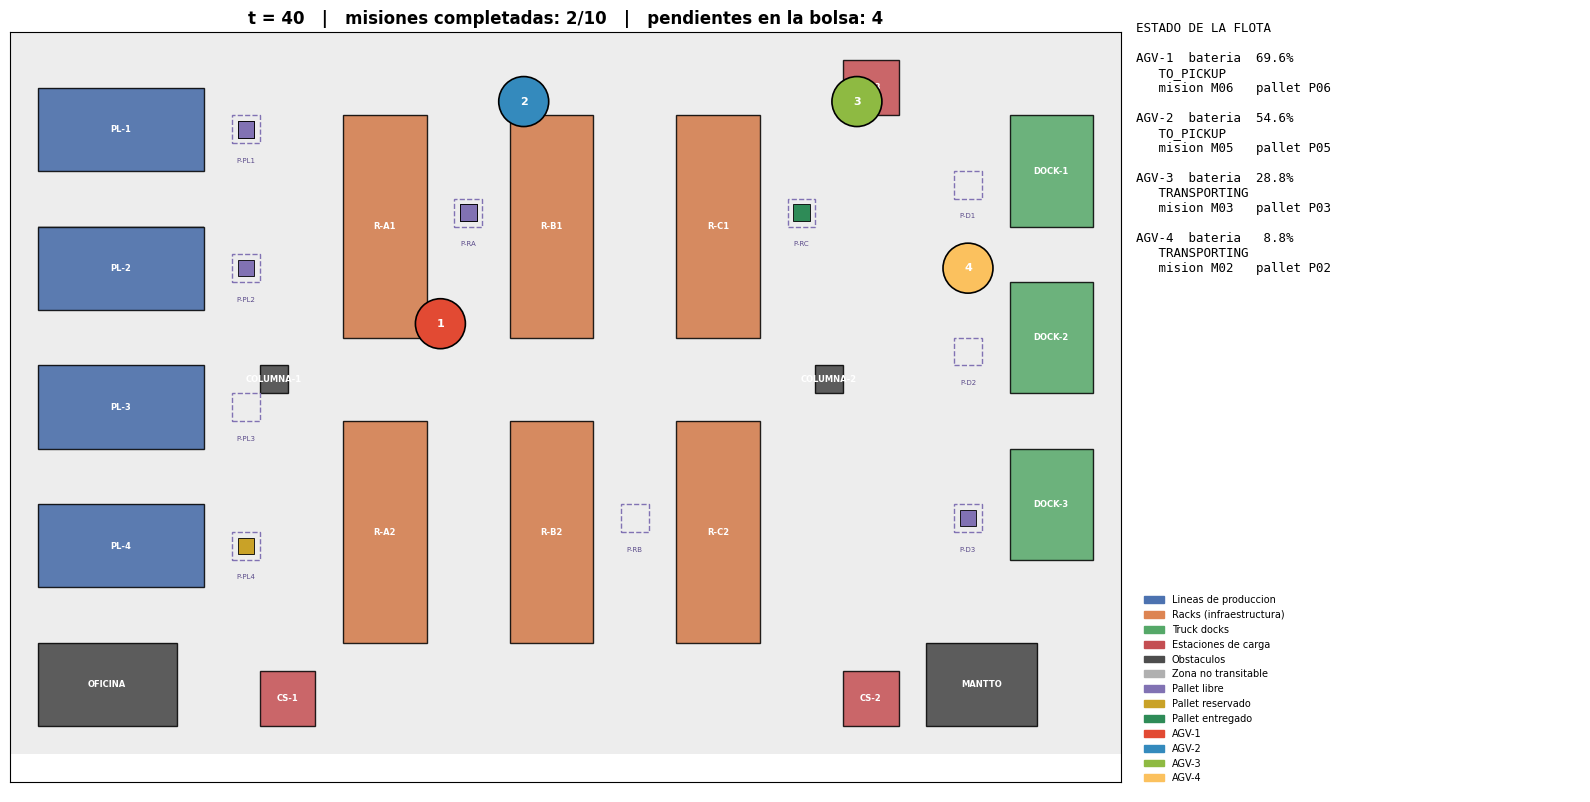

In [38]:
COLOR_PALLET = {
    "STORED": "#8172B3",
    "WAITING_PICKUP": "#8172B3",
    "RESERVED": "#C9A227",
    "IN_TRANSIT": "#333333",
    "DELIVERED": "#2E8B57",
}

LEYENDA = [
    patches.Patch(color=COL["linea"], label="Lineas de produccion"),
    patches.Patch(color=COL["rack"], label="Racks (infraestructura)"),
    patches.Patch(color=COL["dock"], label="Truck docks"),
    patches.Patch(color=COL["carga"], label="Estaciones de carga"),
    patches.Patch(color=COL["obst"], label="Obstaculos"),
    patches.Patch(color="#B0B0B0", label="Zona no transitable"),
    patches.Patch(color=COLOR_PALLET["WAITING_PICKUP"], label="Pallet libre"),
    patches.Patch(color=COLOR_PALLET["RESERVED"], label="Pallet reservado"),
    patches.Patch(color=COLOR_PALLET["DELIVERED"], label="Pallet entregado"),
] + [patches.Patch(color=c, label=a) for a, c, _, _ in CONFIG_AGVS]


def dibujar_zonas(ax):
    grupos = (
        (LINEAS_PRODUCCION, COL["linea"]),
        (RACKS, COL["rack"]),
        (TRUCK_DOCKS, COL["dock"]),
        (ESTACIONES_CARGA, COL["carga"]),
        (OBSTACULOS, COL["obst"]),
    )
    for elementos, color in grupos:
        for nombre, (x, y, w, h) in elementos.items():
            ax.add_patch(patches.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", alpha=0.85))
            ax.text(x + w / 2, y + h / 2, nombre, ha="center", va="center",
                    fontsize=6, color="white", weight="bold")

    for nombre, (x, y) in PALLETS.items():
        ax.add_patch(patches.Rectangle((x, y), 1, 1, facecolor="none",
                                       edgecolor="#8172B3", linewidth=1.0, linestyle="--"))
        ax.text(x + 0.5, y - 0.7, nombre, ha="center", fontsize=5, color="#5B4B8A")


def dibujar_frame(ax, axp, snap):
    ax.clear()
    axp.clear()
    axp.axis("off")

    ax.imshow(grid, cmap=plt.cm.colors.ListedColormap(["#EDEDED", "#B0B0B0"]),
              extent=[0, ANCHO, 0, ALTO], origin="lower")
    dibujar_zonas(ax)

    for p in snap["pallets"]:
        x, y = p["pos"]
        z = 7 if p["status"] == "IN_TRANSIT" else 4   # el pallet cargado va encima del AGV
        ax.add_patch(patches.Rectangle((x + 0.2, y + 0.2), 0.6, 0.6, zorder=z,
                                       facecolor=COLOR_PALLET[p["status"]], edgecolor="black", linewidth=0.6))

    for a in snap["agvs"]:
        x, y = a["pos"]
        ax.add_patch(patches.Circle((x + 0.5, y + 0.5), 0.5, zorder=5,
                                    facecolor=a["color"], edgecolor="white", linewidth=1.4))
        ax.text(x + 0.5, y + 0.5, a["id"][-1], ha="center", va="center", zorder=8,
                fontsize=6, color="white", weight="bold")   # el numero queda encima del pallet

    ax.set_xlim(0, ANCHO)
    ax.set_ylim(-1, ALTO)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"t = {snap['t']}   |   misiones completadas: {snap['completadas']}/{N_MISIONES}"
                 f"   |   pendientes en la bolsa: {snap['pendientes']}", fontsize=12, weight="bold")

    lineas = ["ESTADO DE LA FLOTA", ""]
    for a in snap["agvs"]:
        lineas.append(f"{a['id']}  bateria {a['battery']:5.1f}%")
        lineas.append(f"   {a['status']}")
        lineas.append(f"   mision {a['mision']}   pallet {a['pallet']}")
        lineas.append("")
    axp.text(0, 1, "\n".join(lineas), va="top", ha="left", fontsize=9, family="monospace")
    axp.legend(handles=LEYENDA, loc="lower left", fontsize=7, frameon=False)


fig, (ax, axp) = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [3, 1.2]})
dibujar_frame(ax, axp, snapshots[40])
plt.tight_layout()
plt.show()

### Animacion

Un frame cada dos pasos para que el video este de buen tamaño. Se ve el sistema cambiando en el tiempo: los AGVs saliendo a buscar pallets, los pallets cambiando de color al ser reservados y entregados, y los AGVs que se van a las estaciones de carga.

In [39]:
frames = snapshots[::3]

fig, (ax, axp) = plt.subplots(1, 2, figsize=(13, 6.5), gridspec_kw={"width_ratios": [3, 1.2]})
plt.tight_layout()

anim = FuncAnimation(fig, lambda i: dibujar_frame(ax, axp, frames[i]),
                     frames=len(frames), interval=250, repeat=False)
plt.close(fig)

print(f"Animacion de {len(frames)} cuadros, uno cada 3 pasos de simulacion")
HTML(anim.to_jshtml())

Animacion de 66 cuadros, uno cada 3 pasos de simulacion


---

##Evidencia de comunicacion y negociacion

Tres episodios de subasta tomados del log real: el primero con los cuatro AGVs pujando, uno con AGVs ocupados transportando y uno con un AGV cargando. Despues, la vida completa de una mision de punta a punta.

In [40]:
def imprimir_subasta(mision_id, t):
    print(f"--- Subasta de {mision_id} en t={t} ---")
    for m in bus.read(t=t):
        if m.contenido.get("mision") == mision_id or m.tipo is MessageType.UNAVAILABLE:
            print(formatear(m))
    print()


def imprimir_vida(mision_id):
    print(f"--- Vida completa de {mision_id} ---")
    del_tema = [m for m in bus.history if m.contenido.get("mision") == mision_id]
    convocatorias = [m for m in del_tema if m.tipo is MessageType.MISSION_PUBLISHED]

    print(formatear(convocatorias[0]))
    if len(convocatorias) > 1:
        print(f"[t={convocatorias[0].t:3d}] MANAGER repite la convocatoria {len(convocatorias)} veces, "
              f"hasta t={convocatorias[-1].t}, mientras nadie la toma")
    for m in del_tema:
        if m.tipo is not MessageType.MISSION_PUBLISHED:
            print(formatear(m))
    print()


aceptaciones = bus.read(MessageType.ACCEPT)
no_disponibles = bus.read(MessageType.UNAVAILABLE)
pasos_ocupado = {m.t for m in no_disponibles}
pasos_cargando = {m.t for m in no_disponibles if m.contenido["motivo"].startswith("CHARGING")}

def episodio(pasos):
    return next((m for m in aceptaciones if m.t in pasos), aceptaciones[0])


episodio_1 = aceptaciones[0]
episodio_2 = episodio(pasos_ocupado)
episodio_3 = episodio(pasos_cargando)

imprimir_subasta(episodio_1.contenido["mision"], episodio_1.t)
imprimir_subasta(episodio_2.contenido["mision"], episodio_2.t)
imprimir_subasta(episodio_3.contenido["mision"], episodio_3.t)
imprimir_vida(episodio_3.contenido["mision"])

--- Subasta de M01 en t=1 ---
[t=  1] MANAGER publica M01: P-PL1 -> P-RA (pallet P01)
[t=  1] AGV-1 puja    10.0 por M01
[t=  1] AGV-2 puja   -39.5 por M01
[t=  1] AGV-3 puja   -18.0 por M01
[t=  1] AGV-4 puja   -16.0 por M01
[t=  1] AGV-1 acepta M01 con utilidad 10.0

--- Subasta de M05 en t=27 ---
[t= 27] MANAGER publica M05: P-PL1 -> P-RC (pallet P05)
[t= 27] AGV-1 no disponible (TRANSPORTING M01)
[t= 27] AGV-2 puja   -18.1 por M05
[t= 27] AGV-3 no disponible (TRANSPORTING M03)
[t= 27] AGV-4 no disponible (TRANSPORTING M02)
[t= 27] AGV-2 acepta M05 con utilidad -18.1

--- Subasta de M07 en t=74 ---
[t= 74] MANAGER publica M07: P-RA -> P-D1 (pallet P07)
[t= 74] AGV-1 no disponible (TRANSPORTING M06)
[t= 74] AGV-2 no disponible (TRANSPORTING M05)
[t= 74] AGV-3 no disponible (CHARGING)
[t= 74] AGV-4 puja     5.0 por M07
[t= 74] AGV-4 acepta M07 con utilidad 5.0

--- Vida completa de M07 ---
[t=  1] MANAGER publica M07: P-RA -> P-D1 (pallet P07)
[t=  1] MANAGER repite la convocatoria 74

### Recargas y volumen de mensajes

In [41]:
print("--- Idas a cargar ---")
for m in bus.read(MessageType.CHARGING):
    print(formatear(m))

print("\n--- Mensajes por tipo ---")
for tipo in MessageType:
    print(f"{tipo.name:20s} {len(bus.read(tipo))}")
print(f"{'TOTAL':20s} {len(bus.history)}")

--- Idas a cargar ---
[t= 45] AGV-4 va a cargar a CS-3 con bateria 6%
[t= 49] AGV-3 va a cargar a CS-3 con bateria 23%
[t=131] AGV-2 va a cargar a CS-3 con bateria 0%
[t=163] AGV-1 va a cargar a CS-3 con bateria 0%

--- Mensajes por tipo ---
MISSION_PUBLISHED    392
BID                  61
UNAVAILABLE          378
ACCEPT               10
PICKED_UP            10
COMPLETED            10
CHARGING             4
TOTAL                865


---

##Resultados y metricas



In [42]:
df_agvs = pd.DataFrame([{
    "AGV": a.agv_id,
    "misiones_completadas": a.completadas,
    "distancia_recorrida": a.distancia,
    "bateria_final": round(a.battery, 1),
    "estado_final": a.status.name,
} for a in model.agvs])

df_resultado = pd.DataFrame([{
    "mision": m.id,
    "flujo": m.flujo,
    "agv": m.agv_id,
    "t_aceptada": m.t_aceptada,
    "t_completada": m.t_completada,
    "duracion": None if m.t_completada is None else m.t_completada - m.t_aceptada,
    "status": m.status.name,
} for m in misiones.values()])

display(df_agvs)
display(df_resultado)

print("Pasos simulados:", model.t)
print("Misiones completadas:", len(model.manager.completadas), "de", len(misiones))
print("Misiones pendientes:", len(model.manager.bolsa()))
print("Distancia total de la flota:", int(df_agvs["distancia_recorrida"].sum()), "celdas")
print("Duracion promedio de una mision:", round(df_resultado["duracion"].mean(), 1), "pasos")

,AGV,misiones_completadas,distancia_recorrida,bateria_final,estado_final
0,AGV-1,3,169,100.0,AVAILABLE
1,AGV-2,3,132,100.0,AVAILABLE
2,AGV-3,2,101,61.6,AVAILABLE
3,AGV-4,2,94,64.0,AVAILABLE


,mision,flujo,agv,t_aceptada,t_completada,duracion,status
0,M01,Produccion -> Rack,AGV-1,1,35,34,COMPLETED
1,M02,Produccion -> Dock OUT,AGV-4,1,44,43,COMPLETED
2,M03,Rack -> Dock OUT,AGV-3,1,48,47,COMPLETED
3,M04,Dock IN -> Rack,AGV-2,1,26,25,COMPLETED
4,M05,Produccion -> Rack,AGV-2,27,78,51,COMPLETED
5,M06,Produccion -> Dock OUT,AGV-1,36,96,60,COMPLETED
6,M07,Rack -> Dock OUT,AGV-4,74,120,46,COMPLETED
7,M08,Dock IN -> Rack,AGV-3,75,124,49,COMPLETED
8,M09,Produccion -> Rack,AGV-2,79,130,51,COMPLETED
9,M10,Produccion -> Dock OUT,AGV-1,97,162,65,COMPLETED


Pasos simulados: 197
Misiones completadas: 10 de 10
Misiones pendientes: 0
Distancia total de la flota: 496 celdas
Duracion promedio de una mision: 47.1 pasos


### Graficas

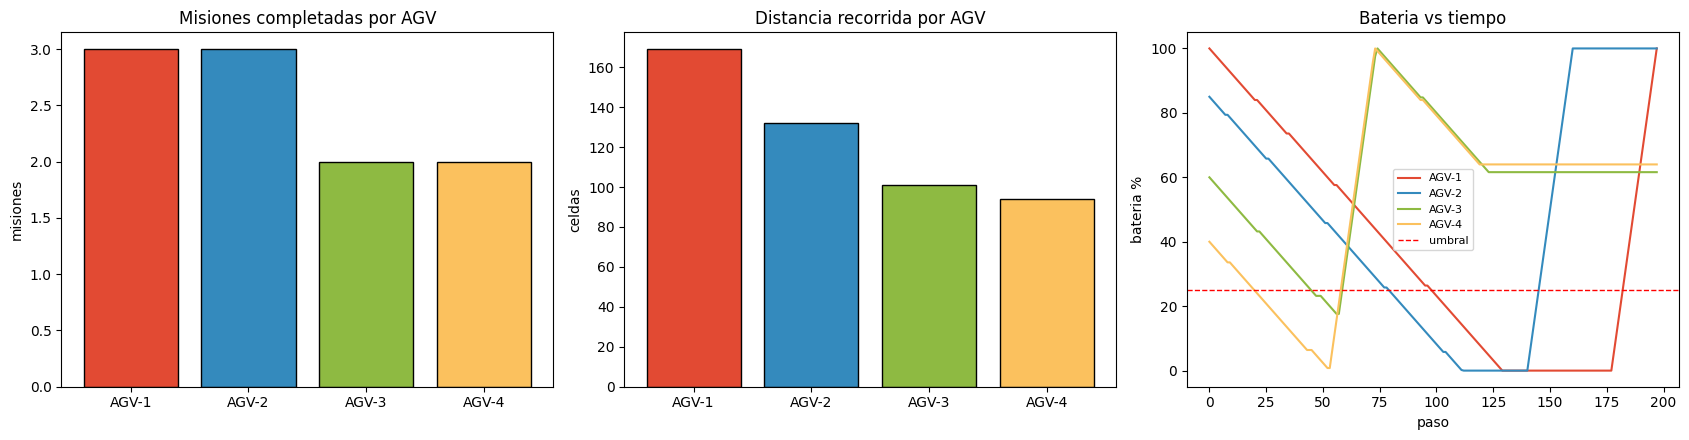

In [43]:
colores = [a.color for a in model.agvs]
ts = [s["t"] for s in snapshots]
bateria_por_agv = {a["id"]: [] for a in snapshots[0]["agvs"]}
for s in snapshots:
    for a in s["agvs"]:
        bateria_por_agv[a["id"]].append(a["battery"])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].bar(df_agvs["AGV"], df_agvs["misiones_completadas"], color=colores, edgecolor="black")
axes[0].set_title("Misiones completadas por AGV")
axes[0].set_ylabel("misiones")

axes[1].bar(df_agvs["AGV"], df_agvs["distancia_recorrida"], color=colores, edgecolor="black")
axes[1].set_title("Distancia recorrida por AGV")
axes[1].set_ylabel("celdas")

for agv in model.agvs:
    axes[2].plot(ts, bateria_por_agv[agv.agv_id], color=agv.color, label=agv.agv_id)
axes[2].axhline(BATERIA_UMBRAL, color="red", linestyle="--", linewidth=1, label="umbral")
axes[2].set_title("Bateria vs tiempo")
axes[2].set_xlabel("paso")
axes[2].set_ylabel("bateria %")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---

## Fase 9. Analisis

**1. Como representamos cada AGV como agente autonomo**

Con la clase AGVAgent. Cada instancia tiene sus propios atributos y decide sola: nadie le dice que mision tomar. El ciclo es perceive para leer el bus, evaluate_mission para calcular su utilidad, bid para publicar su puja y act para ejecutar su maquina de estados.

**2. Que informacion contiene el estado interno**

position, battery, status y mission, mas pallet que trae cargado, ruta que le falta recorrer, distancia acumulada, completadas, su color y su agv_id. Los cuatro empiezan con posicion y bateria distintas, no son copias del mismo punto.

**3. Como se representan las misiones**

Con el dataclass Mission: id, flujo, origen y destino como nombre de punto y como coordenada, pallet_id y status del enum MissionStatus que va PENDING -> ACCEPTED -> IN_PROGRESS -> COMPLETED. Guarda ademas el AGV que la ejecuto y los tiempos de publicacion, aceptacion y cierre, que son los que alimentan la tabla de la Fase 8.

**4. Como se comunica una nueva mision**

MissionManager.publicar mete al MessageBus un mensaje MISSION_PUBLISHED por cada mision que sigue en la bolsa, con emisor MANAGER y receptor TODOS. Se repite cada paso mientras nadie la tome, porque un AGV ocupado en el paso 10 debe poder enterarse en el paso 74. En el log de la Fase 7 se ve que M07 se convoco 83 veces antes de que AGV-4 quedara libre y la tomara.

**5. Que informacion usa un AGV para decidir**

Su distancia Manhattan al origen de la mision, su bateria y su carga de trabajo, combinadas en utilidad. La distancia sale de su propia posicion, no se la da nadie. Ademas revisa dos filtros: `disponible`, que exige estar AVAILABLE y con bateria arriba de 25%, y `alcanza_bateria`, que estima con `costo_estimado` lo que cuesta la mision completa mas la salida al cargador y descarta las que no puede terminar. Solo puja por lo que le queda dentro del presupuesto de bateria.

**6. Como negocian cuando varios quieren la misma mision**

Subasta. Cada AGV publica un mensaje BID con su utilidad. resolver_subasta toma las pujas del bus y devuelve la mayor, con desempate por ID menor. El ganador publica ACCEPT y el manager solo registra. En t=1 se convocaron las diez misiones a la vez: AGV-1 pujo por las diez, AGV-2 por las diez, AGV-3 solo por M03, M04 y M07 porque con 60% no le alcanzaba para las demas, y AGV-4 publico no disponible por bateria insuficiente. M01 la gano AGV-1 con 10.0 contra -39.5 de AGV-2, porque era el mas cercano al origen.

**7. Como evitan ejecutar la misma mision dos veces**

Al ser aceptada, la mision pasa a ACCEPTED y bolsa() deja de devolverla, asi que ya no se publica ni se puede pujar por ella. Ademas resolver_subastas saca de la ronda al AGV que acaba de ganar, para que no se lleve dos misiones en el mismo paso. Una verificacion confirma que no hay ACCEPT repetidos.

**8. Donde se observa la colaboracion**

En tres lugares. Los mensajes UNAVAILABLE, donde un AGV ocupado, cargando o sin bateria suficiente avisa a la flota que no cuenten con el y por que. En la corrida hay 4 mensajes de "bateria insuficiente", que es un AGV libre declarando que se retira de la subasta porque no podria terminar lo que se esta convocando, y asi deja el campo a quien si puede. El termino L_i de la utilidad, que hace que el AGV que ya completo misiones puje mas bajo y ceda las siguientes, lo que reparte la carga en 3, 3, 2 y 2 misiones. Y el hecho de que la mision aceptada desaparezca de la bolsa, que evita que dos AGVs se estorben yendo por el mismo pallet.

**9. Como afecta la bateria**

Debajo de 25% el AGV deja de pujar, publica UNAVAILABLE y se va a la estacion de carga mas cercana, donde recupera 5% por paso. Si cae debajo del umbral con una mision en curso, la termina primero. La bateria tambien decide antes del umbral: `necesita_cargar` manda a cargar al AGV que sigue arriba de 25% pero para el que ninguna mision publicada es viable. En la corrida se ven cinco idas a cargar y la primera es justo de ese tipo: AGV-4 sale a cargar en t=1 con 40%, no porque cruzara el umbral sino porque calculo que ninguna de las diez misiones convocadas le alcanzaba. Ningun AGV llega a 0% en toda la corrida, los minimos son 36.8%, 25.6%, 17.6% y 20.8%.

**10. Limitaciones de la estrategia actual**

- La subasta solo toma en cuenta el presente: decide con la informacion del instante y no considera donde queda el AGV despues de entregar.
- No hay evasion de colisiones, dos AGVs pueden ocupar la misma celda.
- Los pesos de la utilidad son fijos y elegidos a mano.
- No hay reasignacion: si un AGV se quedara atorado, su mision no vuelve a la bolsa.
- El filtro de bateria es una guardia binaria, no una decision: `alcanza_bateria` responde puedo o no puedo, nunca me conviene o no. Y sus constantes, `FACTOR_RODEO = 1.2` y `RESERVA_BATERIA = 10`, se estimaron a mano sobre distancia Manhattan, no sobre la ruta BFS real, asi que es conservador de mas en unas zonas y de menos en otras.
- La carga es todo o nada: el AGV se queda en la estacion hasta 100% aunque con la mitad ya pudiera atender una mision cercana.
- El ruteo es greedy y recalcula BFS sin considerar el trafico de los demas.

**11. Que componente mejorariamos con una tecnica inteligente en M4**

La decision de aceptar o rechazar, y la de cuando ir a cargar. Hoy la subasta optimiza el costo inmediato de llegar al origen, pero ignora el valor futuro de la posicion en la que queda el AGV. Un AGV puede ganar una mision que lo deja en la esquina opuesta del almacen justo antes de que se publique una mision mejor cerca de donde estaba, y ese costo no aparece en `U_ik`. Lo mismo pasa con la bateria. El filtro de viabilidad evita el desastre de quedarse en 0%, pero no elige bien el momento: en t=1 AGV-4 se va a cargar con 40% y se queda en la estacion hasta llegar a 100%, y mientras tanto M10 espera 142 pasos en la bolsa. Cargar hasta el tope, cargar lo justo para una mision corta o esperar a que se libere una mision cercana son tres acciones que la formula lineal no puede ni comparar, porque no tiene forma de valorar el estado futuro.

Eso se ataca con una politica aprendida sobre un estado compacto, por ejemplo (zona del almacen, nivel de bateria, tipo de mision, distancia al cargador), donde la accion sea pujar, no pujar o ir a cargar, y la recompensa combine misiones completadas contra distancia en vacio y penalizacion por quedarse sin bateria. Con eso el AGV aprende a rechazar misiones que hoy acepta, algo que la formula lineal con pesos fijos no puede representar.